In [589]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [590]:
import pandas as pd
import numpy as np
import globals
from pathlib import Path
import matplotlib.pyplot as plt

In [594]:
trait_df = pd.read_pickle('/Users/benny/Documents/swc/trait_analyses/trait_dataframes/df1.csv') 

In [596]:
trait_df

,date,Session identifier,GAD_total,AQ_total,BIS_total,opponent,proportion_score,proportion_wins,scores_per_unit_time_socials,scores_per_unit_time_solos,slice_onset_centrality_social,slice_onset_centrality_solo,slice_onset_centrality_first_solo,slice_onset_centrality_second_solo,shift_class
pseudonym,,,,,,,,,,,,,,,
EN27,2024-09-27,2024-09-27_Session1_Guest_Emily,7.0,5.0,23.0,SH27,0.424063,0.426357,8.431171,4.691789,0.656108,0.686288,0.672550,0.700027,NO RELIABLE SHIFT
SH27,2024-09-27,2024-09-27_Session1_Host_Sara,1.0,9.0,15.0,EN27,0.575937,0.573643,5.045425,4.853478,0.757652,0.730982,0.716209,0.745756,NO RELIABLE SHIFT
AW17,2024-10-17,2024-10-17_Session1_Guest_Abigail,5.0,9.0,11.0,SP17,0.374384,0.384615,7.464551,5.108392,0.671236,0.698695,0.646490,0.750899,POST-SOCIAL SHIFT
SP17,2024-10-17,2024-10-17_Session1_Host_Shameer,1.0,1.0,15.0,AW17,0.625616,0.615385,5.407391,3.647108,0.454723,0.390838,0.340966,0.440710,SUSTAINED SHIFT
FA12,2024-11-12,2024-11-12_Session2_Host_Francesca,1.0,0.0,10.0,SL12,0.420091,0.396396,10.612636,6.830634,0.710813,0.518371,0.270422,0.766321,CONTINUED SHIFT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MI27,2026-03-27,2026-03-27_Session1_Host_Mariam,1.0,1.0,22.0,YZ27,0.564477,0.549020,10.743446,7.123255,0.710401,0.688827,0.706158,0.671496,POST-SOCIAL SHIFT
RW27,2026-03-27,2026-03-27_Session2_Guest_Rebecca,1.0,2.0,16.0,DT27,0.420035,0.441379,6.881704,6.490427,0.250744,0.169072,0.191825,0.146320,ADAPT & REVERSE
YZ27,2026-03-27,2026-03-27_Session1_Guest_Yixin,2.0,1.0,11.0,MI27,0.435523,0.450980,7.780860,7.144364,0.303364,0.427028,0.396952,0.457105,ADAPT & REVERSE


In [597]:
# binarising shift class based on whether a social shift happened or not regardless of second solo behaviour
for pseudo in trait_df.index:
    if trait_df.loc[pseudo,'shift_class']=='NO RELIABLE SHIFT' or trait_df.loc[pseudo,'shift_class']=='SHIFT POST SOCIAL':
        trait_df.loc[pseudo,'binary_shift_class']='NO solo-social SHIFT'
    else:
        trait_df.loc[pseudo,'binary_shift_class']='solo-social SHIFT'

## Pie chart for adaptation categories

In [599]:
from pypalettes import load_cmap
from pypalettes import load_palette
cmap = load_cmap("excel_Slipstream")
colors = load_palette("excel_Slipstream")
label_colors = colors

In [600]:
# fractions of different adaptation categories
shift_class = trait_df['shift_class'].tolist()

from collections import Counter
items = list(Counter(shift_class).keys())
counts = list(Counter(shift_class).values())

In [605]:
df = pd.DataFrame(
    {"counts": counts},
    index=items,
)

([<matplotlib.patches.Wedge at 0x310545590>,
 [Text(1.0080029605882839, 0.4881905687795033, 'NO RELIABLE SHIFT'),
  Text(0.22490386427188916, 1.0971865164298966, 'POST-SOCIAL SHIFT'),
  Text(-0.8999166348662523, 0.6667458663471417, 'SUSTAINED SHIFT'),
  Text(-0.8787453895205076, -0.6944109304989746, 'CONTINUED SHIFT'),
  Text(0.680660727709667, -0.8894385722205592, 'ADAPT & REVERSE')],
 [Text(0.6300018503676773, 0.3051191054871895, '14.4%'),
  Text(0.1405649151699307, 0.6857415727686853, '14.9%'),
  Text(-0.5624478967914076, 0.4167161664669635, '21.3%'),
  Text(-0.5492158684503171, -0.4340068315618591, '20.3%'),
  Text(0.4254129548185418, -0.5558991076378494, '29.2%')])

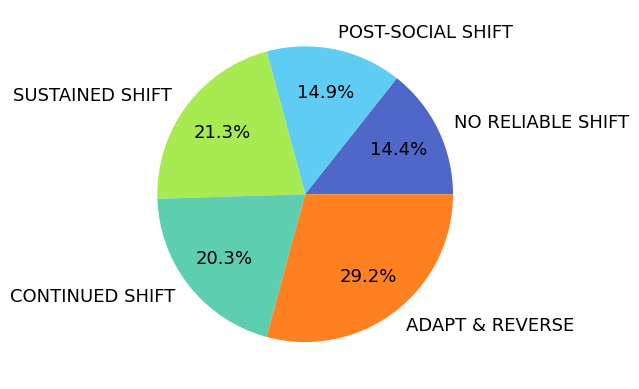

In [607]:
fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

In [608]:
# fractions of different BINARY adaptation categories
binary_shift_class = trait_df['binary_shift_class'].tolist()

from collections import Counter
items = list(Counter(binary_shift_class).keys())
counts = list(Counter(binary_shift_class).values())

In [610]:
df = pd.DataFrame(
    {"counts": counts},
    index=items,
)

([<matplotlib.patches.Wedge at 0x30f6f9a90>,
 [Text(1.0080029605882839, 0.4881905687795033, 'NO solo-social SHIFT'),
  Text(-1.0080029324585182, -0.4881906268610943, 'solo-social SHIFT')],
 [Text(0.6300018503676773, 0.3051191054871895, '14.4%'),
  Text(-0.6300018327865738, -0.3051191417881839, '85.6%')])

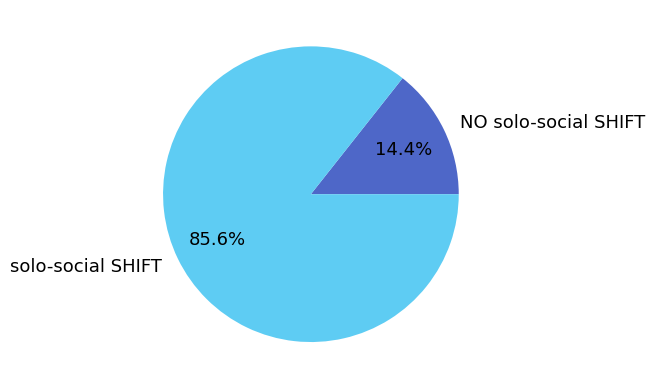

In [612]:
fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

## Confusion matrix for dyads

In [617]:
opponents = list(trait_df['opponent'])

In [618]:
shift_class_player = shift_class
binary_shift_class_player = binary_shift_class

In [619]:
shift_class_opponent = []
binary_shift_class_opponent = []
for i, opponent in enumerate(opponents):
    shift_class = trait_df['shift_class'][opponent]
    binary_shift_class =  trait_df['binary_shift_class'][opponent]
    shift_class_opponent.append(shift_class)
    binary_shift_class_opponent.append(binary_shift_class)

trait_df['shift_class_opponent'] = shift_class_opponent
trait_df['binary_shift_class_opponent'] = binary_shift_class_opponent

In [620]:
# Importing LabelEncoder from Sklearn 
# library from preprocessing Module.
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()

# Using .fit_transform function to fit label
# encoder and return encoded label
player_labels = le.fit_transform(shift_class_player)
opponent_labels = le.fit_transform(shift_class_opponent)

binary_player_labels = le.fit_transform(binary_shift_class_player)
binary_opponent_labels = le.fit_transform(binary_shift_class_opponent)

In [147]:
# confusion matrices

# 1. likelihood of pairings

In [646]:
len(shift_class_player)

202

In [659]:
dyads_once = {}

for pseudo, opp, player_class, opp_class in zip(
    pseudonyms,
    opponents,
    shift_class_player,
    shift_class_opponent
):
    # unique session/dyad identity, order-invariant
    dyad_id = tuple(sorted([pseudo, opp]))

    # class composition, order-invariant
    dyad_class = tuple(sorted([player_class, opp_class]))

    # keep only one row per real dyad
    if dyad_id not in dyads_once:
        dyads_once[dyad_id] = dyad_class

dyad_class_counts = Counter(dyads_once.values())

sorted_counts = sorted(dyad_class_counts.items())

types_of_dyads = [dyad for dyad, freq in sorted_counts]
frequency_of_dyads = [freq for dyad, freq in sorted_counts]

In [689]:
binary_dyads_once = {}

for pseudo, opp, player_class, opp_class in zip(
    pseudonyms,
    opponents,
    binary_shift_class_player,
    binary_shift_class_opponent
):
    # unique session/dyad identity, order-invariant
    binary_dyad_id = tuple(sorted([pseudo, opp]))

    # class composition, order-invariant
    binary_dyad_class = tuple(sorted([player_class, opp_class]))

    # keep only one row per real dyad
    if binary_dyad_id not in binary_dyads_once:
        binary_dyads_once[binary_dyad_id] = binary_dyad_class

binary_dyad_class_counts = Counter(binary_dyads_once.values())

binary_sorted_counts = sorted(binary_dyad_class_counts.items())

binary_types_of_dyads = [dyad for dyad, freq in binary_sorted_counts]
binary_frequency_of_dyads = [freq for dyad, freq in binary_sorted_counts]

In [671]:
import seaborn as sns

In [672]:
cmap = load_cmap("Mint")

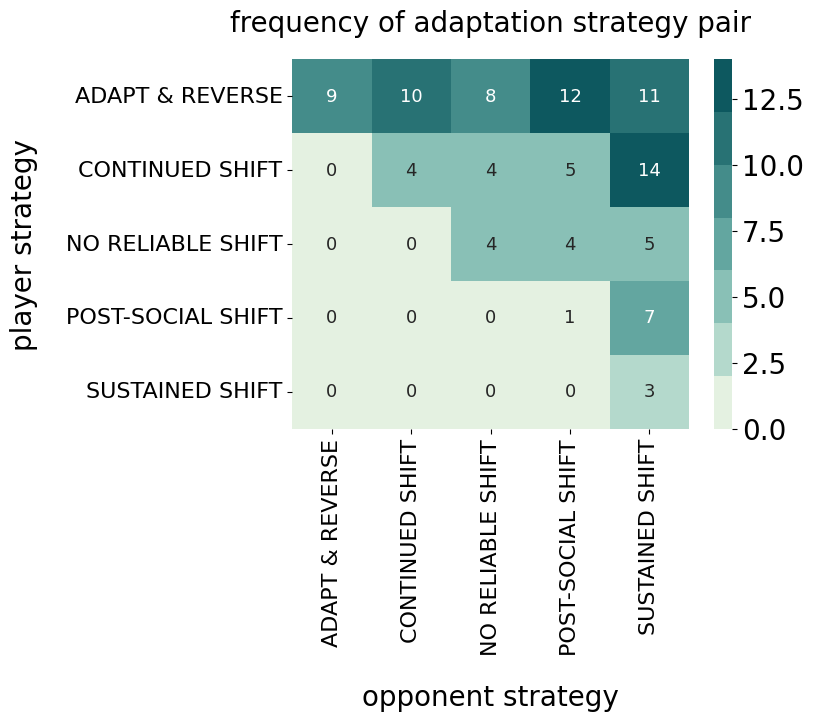

In [667]:
cm = pd.DataFrame(
    0,
    index=sorted(set(shift_class_player)),
    columns=sorted(set(shift_class_opponent))
)

for (player,opponent), freq in dyad_class_counts.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap, annot_kws={"size":13})

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("frequency of adaptation strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

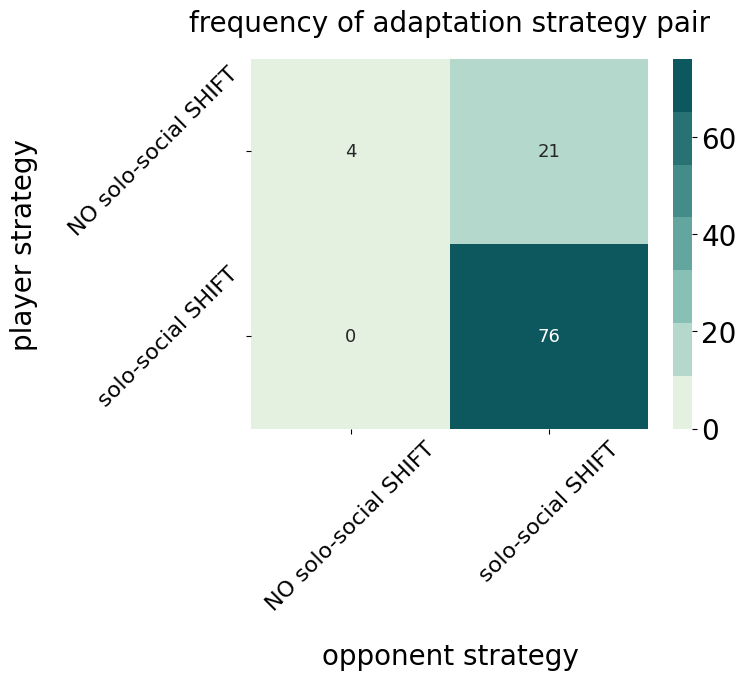

In [673]:
cm = pd.DataFrame(
    0,
    index=sorted(set(binary_shift_class_player)),
    columns=sorted(set(binary_shift_class_opponent))
)

for (player,opponent), freq in binary_dyad_class_counts.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap, annot_kws={"size":13})

ax = plt.gca()
ax.tick_params(axis='both', rotation=45, labelsize=16)

ax.set_title("frequency of adaptation strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

In [ ]:
# confusion matrices

# 2. proportion scores

In [675]:
proportion_scores = list(trait_df['proportion_score'])

In [693]:
def make_score_heatmap_data(
    df,
    row_col,
    col_col,
    value_col='proportion_score',
    aggfunc='mean'
):
    return pd.pivot_table(
        df,
        values=value_col,
        index=row_col,
        columns=col_col,
        aggfunc=aggfunc
    )

In [694]:
heatmap_data_full = make_score_heatmap_data(
    trait_df,
    row_col='shift_class',
    col_col='shift_class_opponent'
)

heatmap_data_binary = make_score_heatmap_data(
    trait_df,
    row_col='binary_shift_class',
    col_col='binary_shift_class_opponent'
)

In [698]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='shift_class',
    columns='shift_class_opponent',
    aggfunc='mean'
)

In [285]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='binary_shift_class',
    columns='binary_shift_class_opponent',
    aggfunc='mean'
)

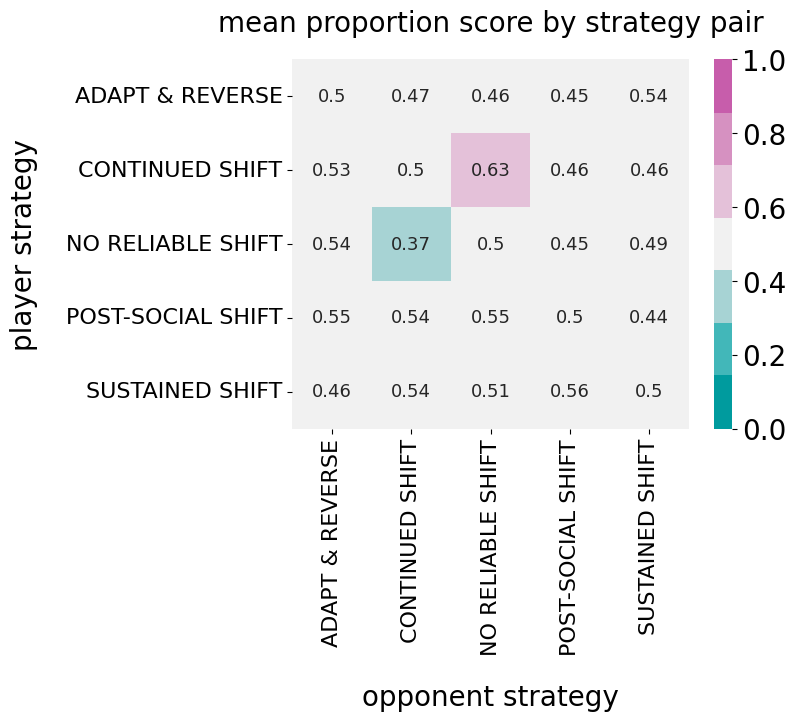

In [699]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean proportion score by strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

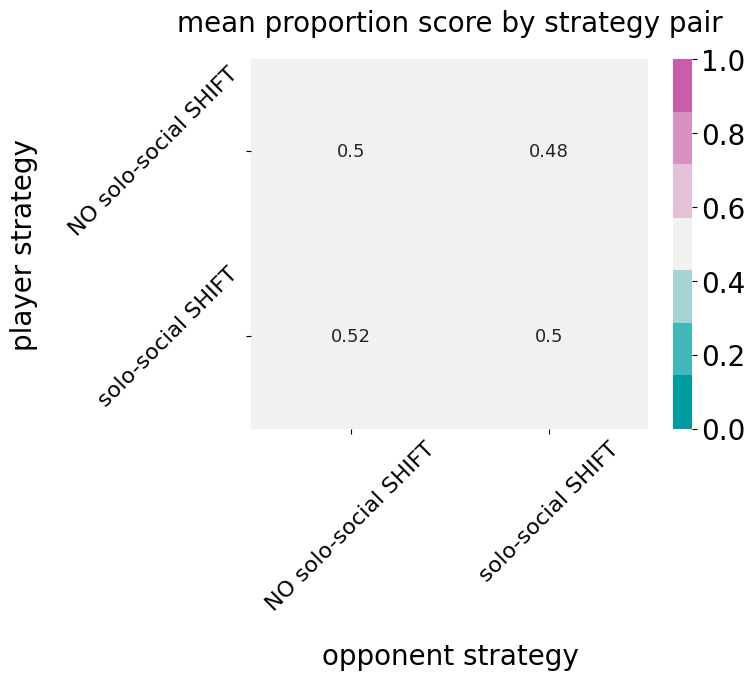

In [701]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data_binary,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',rotation=45,labelsize=16)

ax.set_title("mean proportion score by strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

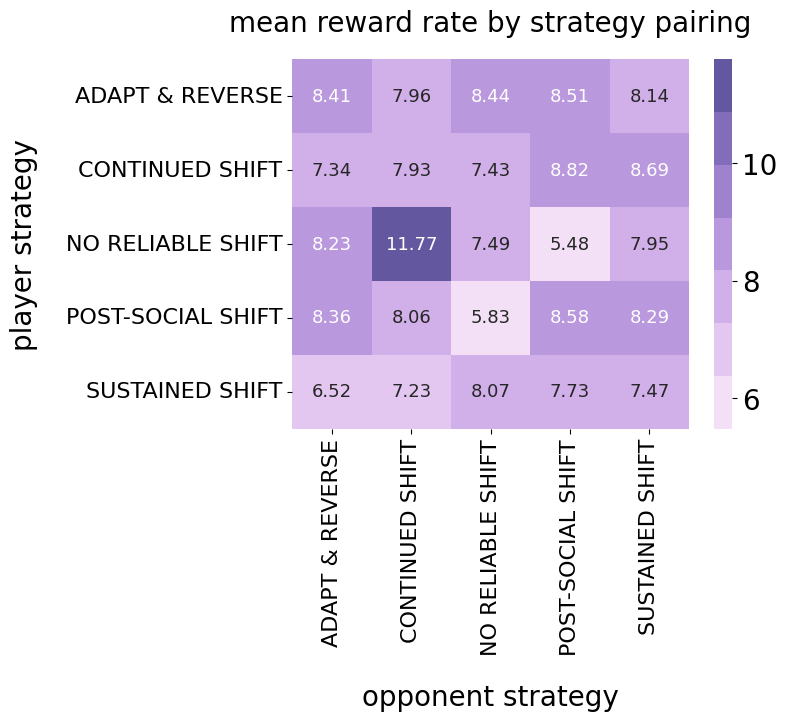

In [702]:
scores_per_second_matrix = pd.pivot_table(
    trait_df,
    values='scores_per_unit_time_socials',
    index='shift_class',
    columns='shift_class_opponent',
    aggfunc='mean'
)

cmap = load_cmap("Purp")

sns.heatmap(
    scores_per_second_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean reward rate by strategy pairing", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

# cells: when row strategy meets column strategy, the former gets X points/s average

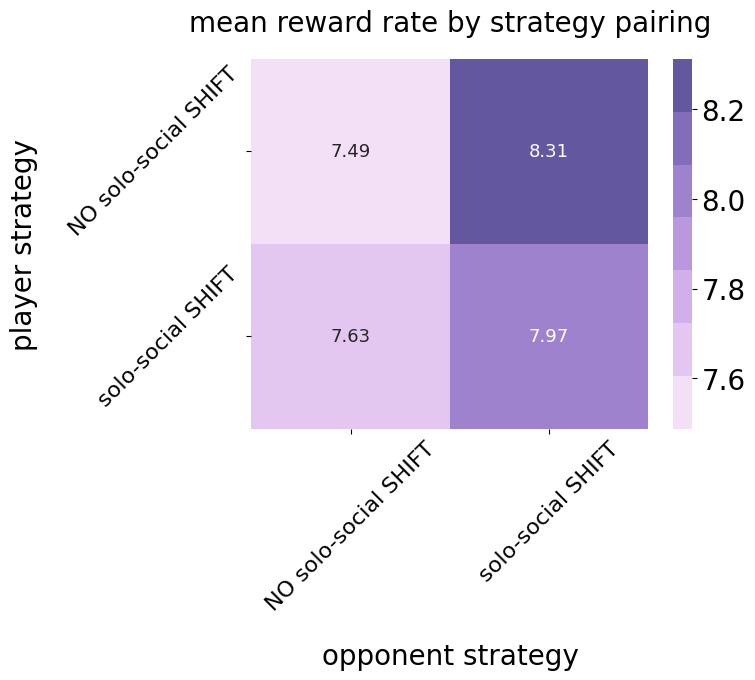

In [704]:
scores_per_second_matrix = pd.pivot_table(
    trait_df,
    values='scores_per_unit_time_socials',
    index='binary_shift_class',
    columns='binary_shift_class_opponent',
    aggfunc='mean'
)

cmap = load_cmap("Purp")

sns.heatmap(
    scores_per_second_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 13}
)

ax = plt.gca()
ax.tick_params(axis='both',rotation=45,labelsize=16)

ax.set_title("mean reward rate by strategy pairing", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

# cells: when row strategy meets column strategy, the former gets X points/s average

In [705]:
scores_per_second_matrix

binary_shift_class_opponent,NO solo-social SHIFT,solo-social SHIFT
binary_shift_class,,
NO solo-social SHIFT,7.487870,8.312448
solo-social SHIFT,7.633535,7.973118


## Proactive/fast reactive vs slow reactive adaptation

### Change in centrality between final 20% of first solo to first 10-15% of social

In [708]:
occupancy_dict = pd.read_pickle('/Users/benny/Documents/swc/pickled_df/occupancy_dict.pkl') 

In [709]:
raw_social_centrality = occupancy_dict['socials']['raw_values']
raw_first_solo_centrality = occupancy_dict['first_solos']['raw_values']
raw_second_solo_centrality = occupancy_dict['second_solos']['raw_values']

In [710]:
occupancy_dict['first_solos']['final_20_pct'] = {}
occupancy_dict['socials']['first_10_pct'] = {}
occupancy_dict['socials']['first_20_pct'] = {}

occupancy_dict['first_solos']['final_20_pct']['values'] = {}
occupancy_dict['socials']['first_10_pct']['values'] = {}
occupancy_dict['socials']['first_20_pct']['values'] = {}


occupancy_dict['first_solos']['final_20_pct']['mean'] = {}
occupancy_dict['socials']['first_10_pct']['mean'] = {}
occupancy_dict['socials']['first_20_pct']['mean'] = {}


In [711]:
for pseudo in trait_df.index:

    centralities_solo = raw_first_solo_centrality[pseudo]
    centralities_social = raw_social_centrality[pseudo]

    trial_length_solo = len(centralities_solo[0])
    trial_length_social = len(centralities_social)

    window_length_solo = int(trial_length_solo - np.round(trial_length_solo/5))
    window_length_social = int(trial_length_solo - np.round(trial_length_solo/10))
    window_length_social_20 = int(trial_length_solo - np.round(trial_length_solo/5))

    final_20_pct = centralities_solo[0][window_length_solo:]
    first_10_pct = centralities_social[1:window_length_social]
    first_20_pct = centralities_social[1:window_length_social]

    occupancy_dict['first_solos']['final_20_pct']['values'][pseudo] = final_20_pct
    occupancy_dict['socials']['first_10_pct']['values'][pseudo] = first_10_pct
    occupancy_dict['socials']['first_20_pct']['values'][pseudo] = first_20_pct

    occupancy_dict['first_solos']['final_20_pct']['mean'][pseudo] = np.nanmean(final_20_pct)
    occupancy_dict['socials']['first_10_pct']['mean'][pseudo] = np.nanmean(first_10_pct)
    occupancy_dict['socials']['first_20_pct']['mean'][pseudo] = np.nanmean(first_20_pct)


In [712]:
import math

In [713]:
seen_pairs = set()
pseudo_tuples_list = []
for i in range(len(trait_df)):
    player = trait_df.index[i]
    opponent = trait_df['opponent'].iloc[i]
    pair = frozenset([player, opponent])
    if pair not in seen_pairs:
        pseudo_tuples_list.append([player, opponent])
        seen_pairs.add(pair)

In [714]:
n_plots = len(pseudo_tuples_list)
n_cols = 10
n_rows = math.ceil(n_plots / n_cols)

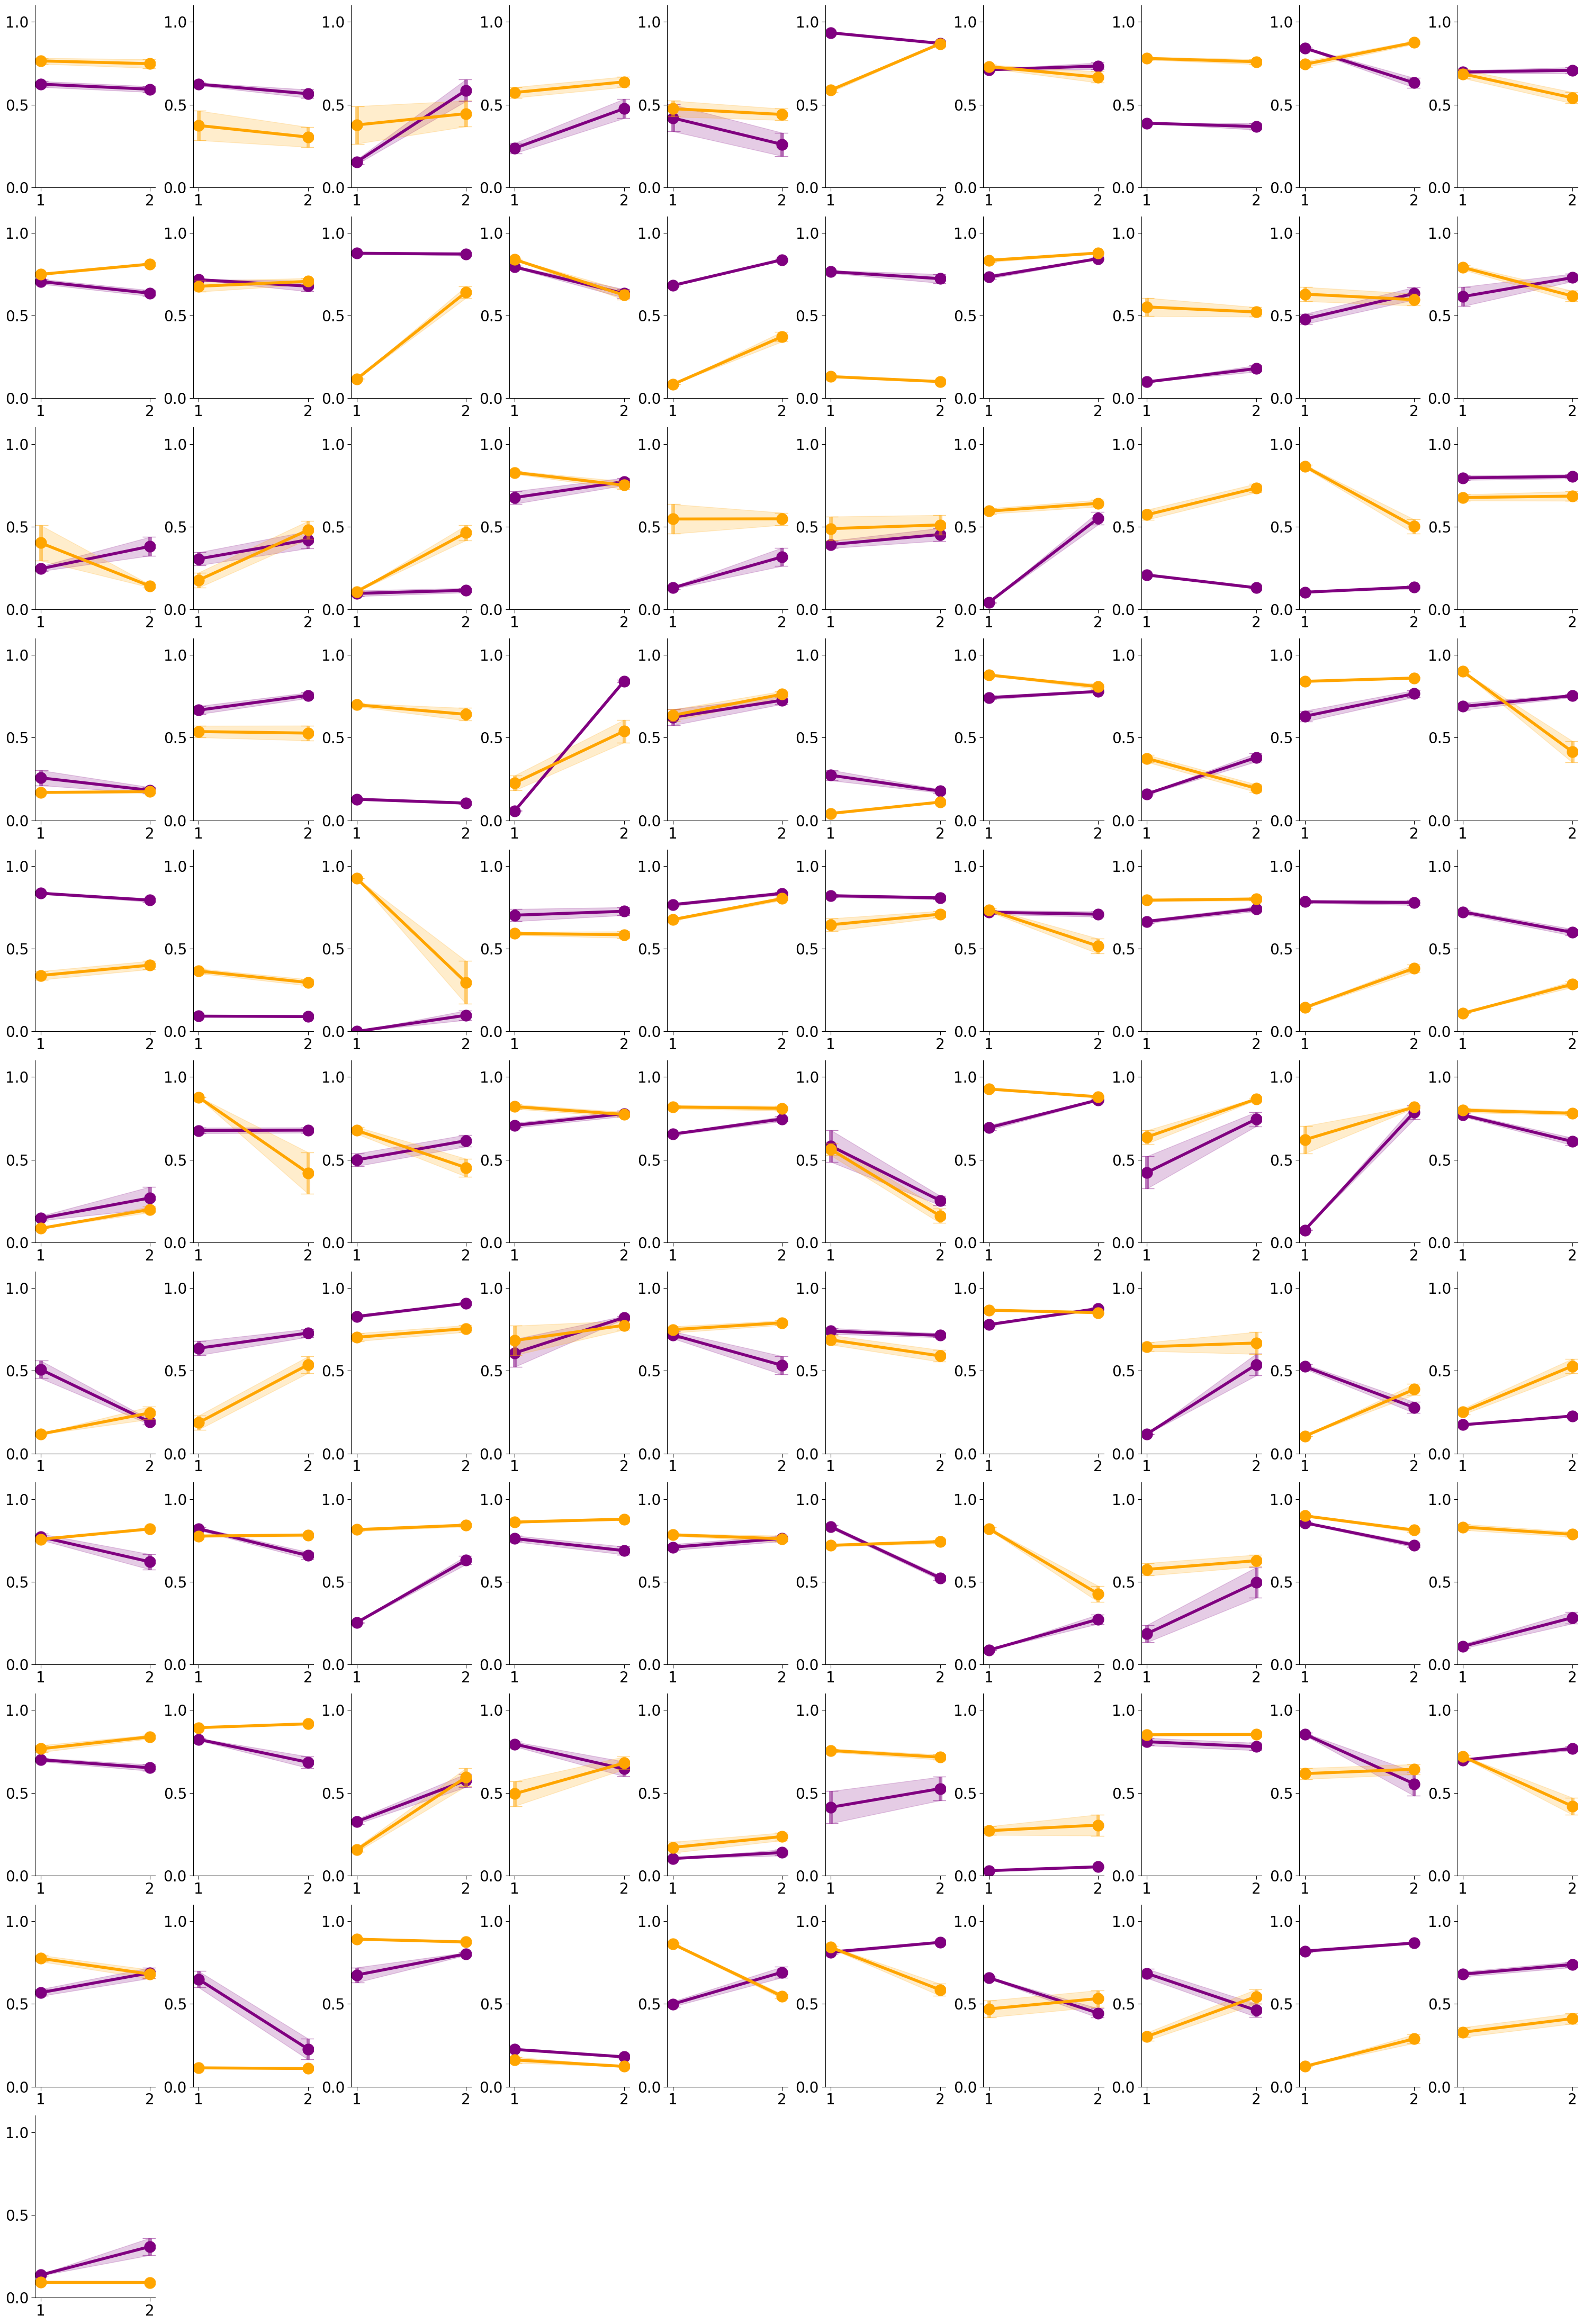

In [715]:
fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3 * n_cols, 4 * n_rows)
)

# Make axs always 2D
axs = np.atleast_2d(axs)

for i in range(n_plots):

    row = i // n_cols
    col = i % n_cols

    ax = axs[row, col]

    for j in range(2):

        pseudonym = pseudo_tuples_list[i][j]

        first_solo = occupancy_dict['first_solos']['final_20_pct']['mean'][pseudonym]
        social = occupancy_dict['socials']['first_20_pct']['mean'][pseudonym]

        first_variance = np.var(occupancy_dict['first_solos']['final_20_pct']['values'][pseudonym])
        social_variance = np.var(occupancy_dict['socials']['first_20_pct']['values'][pseudonym])

        color = 'purple' if j == 0 else 'orange'

        ax.plot(
            [1,2],
            [first_solo, social],
            marker='o',
            markersize=15,
            linestyle='-',
            linewidth=4,
            color=color,
            alpha=1
        )

        # add variance as shaded area around the line
        ax.fill_between(
            [1,2],
            [first_solo - first_variance, social - social_variance],
            [first_solo + first_variance, social + social_variance],
            color=color,
            alpha=0.2
        )

        # add error bars with top and bottom caps
        ax.errorbar(
            [1,2],
            [first_solo, social],
            yerr=[first_variance, social_variance],
            fmt='none',
            ecolor=color,
            elinewidth=5,
            alpha=0.5,
            capsize=10
        )

    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.tick_params(length=5, labelsize=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
total_axes = n_rows * n_cols

for k in range(n_plots, total_axes):

    row = k // n_cols
    col = k % n_cols

    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [371]:
# Could classify as shifting toward/away/with opponent
# Could classify as shift or no shift and replicate above matrices

In [716]:
def shift_no_shift_bootstrap(
    first_solo,
    social,
    n_boot=5000,
    ci=95,
    random_state=None
):

    rng = np.random.default_rng(random_state)

    first_solo = np.asarray(first_solo, dtype=float)
    social = np.asarray(social, dtype=float)

    first_solo = first_solo[~np.isnan(first_solo)]
    social = social[~np.isnan(social)]

    observed_diff = (
        np.mean(social)
        - np.mean(first_solo)
    )

    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):

        first_sample = rng.choice(
            first_solo,
            size=len(first_solo),
            replace=True
        )

        social_sample = rng.choice(
            social,
            size=len(social),
            replace=True
        )

        boot_diffs[i] = (
            np.mean(social_sample)
            - np.mean(first_sample)
        )

    alpha = (100 - ci) / 2

    ci_low, ci_high = np.percentile(
        boot_diffs,
        [alpha, 100 - alpha]
    )

    reliable_shift = (
        (ci_low > 0)
        or
        (ci_high < 0)
    )

    label = (
        'ADAPT'
        if reliable_shift
        else 'NO ADAPT'
    )

    return {
        'label': label,
        'mean_difference': observed_diff,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'reliable_shift': reliable_shift
    }

In [732]:
def classify_dyad_from_bootstrap(
    player_result,
    opponent_result
):
    """
    Classify dyad-level adaptation using bootstrap shift results.

    player_result and opponent_result should be outputs from
    shift_no_shift_bootstrap().
    """

    player_shift = player_result['reliable_shift']
    opponent_shift = opponent_result['reliable_shift']

    g_player = player_result['mean_difference']
    g_opp = opponent_result['mean_difference']

    player_dir = np.sign(g_player)
    opp_dir = np.sign(g_opp)

    if not player_shift and not opponent_shift:
        return 'both stable'

    if player_shift and not opponent_shift:
        return 'player shifts, opponent stable'

    if opponent_shift and not player_shift:
        return 'opponent shifts, player stable'

    if player_shift and opponent_shift:

        if player_dir == opp_dir:
            return 'both shift same direction'

        if player_dir == -opp_dir:
            return 'both shift opposite directions'

    return 'mixed/unclear'

In [733]:
def classify_dyad_bootstrap(
    first_solo_player,
    social_player,
    first_solo_opp,
    social_opp,
    n_boot=5000,
    ci=95,
    random_state=None
):

    player_result = shift_no_shift_bootstrap(
        first_solo_player,
        social_player,
        n_boot=n_boot,
        ci=ci,
        random_state=random_state
    )

    opponent_result = shift_no_shift_bootstrap(
        first_solo_opp,
        social_opp,
        n_boot=n_boot,
        ci=ci,
        random_state=random_state
    )

    dyad_class = classify_dyad_from_bootstrap(
        player_result,
        opponent_result
    )

    return {
        'dyad_class': dyad_class,
        'player_result': player_result,
        'opponent_result': opponent_result
    }

In [380]:
def shift_no_shift(first_solo, social, cutoff=0.2):
    first_solo = np.array(first_solo)
    social = np.array(social)

    first_mean = np.nanmean(first_solo)
    social_mean = np.nanmean(social)

    g = social_mean - first_mean

    if abs(g) < cutoff:
        return 'NO ADAPT'
    if abs(g) >= cutoff:
        return 'ADAPT'

In [438]:
def classify_dyad(g_player, g_opp, cutoff=0.2):

    if abs(g_player) < cutoff and abs(g_opp) < cutoff:
        return 'stable'

    elif (abs(g_player) >= cutoff and abs(g_opp) < cutoff) or (abs(g_opp) >= cutoff and abs(g_player) < cutoff):
        if (np.sign(g_player) == -np.sign(g_opp)) or (np.sign(g_opp) == -np.sign(g_player)) :
            return 'opposite dir stable other'
        elif np.sign(g_player) == np.sign(g_opp):
            return 'same dir stable other'

    #elif abs(g_opp) >= cutoff and abs(g_player) < cutoff:
        #if np.sign(g_opp) == -np.sign(g_player):
            #return 'opposite dir stable plyr'
        #elif np.sign(g_opp) == np.sign(g_player):
            #return 'same dir stable plyr'

    elif abs(g_player) >= cutoff and abs(g_opp) >= cutoff:
        if np.sign(g_player) == -np.sign(g_opp):
            return 'opposite dir'
        elif np.sign(g_player) == np.sign(g_opp):
            return 'same dir'

In [752]:
# first for entire data
shifts = []

for i in range(len(pseudo_tuples_list)):

    for j in range(2):

        pseudonym = pseudo_tuples_list[i][j]

       # first_solo = np.array(occupancy_dict['first_solos']['final_20_pct']['values'][pseudonym])
        #social = np.array(occupancy_dict['socials']['first_20_pct']['values'][pseudonym])
        first_solo = occupancy_dict['first_solos']['raw_values'][pseudonym][0][1::]
        social = occupancy_dict['socials']['raw_values'][pseudonym][1::]

        #shift_pseudo = shift_no_shift(first_solo, social)
        result = shift_no_shift_bootstrap(
            first_solo,
            social
        )
        shift_pseudo = result['label']

        shifts.append(shift_pseudo)

        trait_df.loc[pseudonym, 'binary_shift_class'] = shift_pseudo

In [753]:
# for the early adaptation

shifts = []
dyad_classes = []

for i in range(len(pseudo_tuples_list)):

    player = pseudo_tuples_list[i][0]
    opp = pseudo_tuples_list[i][1]

    first_solo_ply = np.array(occupancy_dict['first_solos']['final_20_pct']['mean'][player])
    social_ply = np.array(occupancy_dict['socials']['first_20_pct']['mean'][player])
    
    first_solo_opp = np.array(occupancy_dict['first_solos']['final_20_pct']['mean'][opp])
    social_opp = np.array(occupancy_dict['socials']['first_20_pct']['mean'][opp])

    result = classify_dyad_bootstrap(
        first_solo_ply,
        social_ply,
        first_solo_opp,
        social_opp)

    dyad_shift_class = result['dyad_class']

    trait_df.loc[player, 'dyad_shift_class'] = dyad_shift_class
    trait_df.loc[opp, 'dyad_shift_class'] = dyad_shift_class 

    for j in range(2):

        pseudonym = pseudo_tuples_list[i][j]

        first_solo = np.array(occupancy_dict['first_solos']['final_20_pct']['values'][pseudonym])
        social = np.array(occupancy_dict['socials']['first_20_pct']['values'][pseudonym])

        #shift_pseudo = shift_no_shift(first_solo, social)
        result = shift_no_shift_bootstrap(
            first_solo,
            social
        )
        shift_pseudo = result['label']

        shifts.append(shift_pseudo)

        trait_df.loc[pseudonym, 'fast_shift_class'] = shift_pseudo


### Pie chart for adaptation categories

### Using the entire first solo and social data

In [754]:
# fractions of different EARLY adaptation categories
binary_shift_class = trait_df['binary_shift_class'].tolist()

from collections import Counter
items = list(Counter(binary_shift_class).keys())
counts = list(Counter(binary_shift_class).values())

([<matplotlib.patches.Wedge at 0x3128ff9d0>,
 [Text(0.6806605721952713, 0.8894386912310517, 'NO ADAPT'),
  Text(-0.6806607064967695, -0.8894385884541546, 'ADAPT')],
 [Text(0.4254128576220445, 0.5558991820194072, '29.2%'),
  Text(-0.4254129415604809, -0.5558991177838465, '70.8%')])

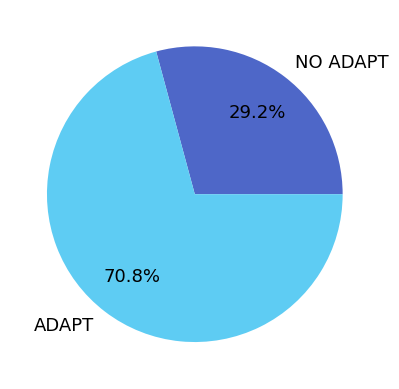

In [755]:
df = pd.DataFrame(
    {"counts": counts},
    index=items,
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

### Early shift class

In [760]:
# fractions of different EARLY adaptation categories
early_shift_class = trait_df['fast_shift_class'].tolist()

from collections import Counter
items = list(Counter(early_shift_class).keys())
counts = list(Counter(early_shift_class).values())

In [748]:
items

['NO ADAPT', 'ADAPT']

([<matplotlib.patches.Wedge at 0x318a516d0>,
 [Text(0.08700578481328283, 1.1166154187584125, 'NO ADAPT'),
  Text(-0.08700582030658946, -1.1166154159928017, 'ADAPT')],
 [Text(0.05437861550830177, 0.6978846367240077, '47.5%'),
  Text(-0.05437863769161841, -0.697884634995501, '52.5%')])

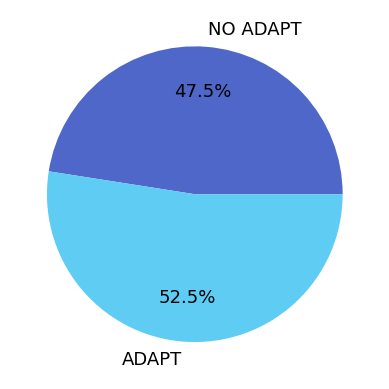

In [761]:
df = pd.DataFrame(
    {"counts": counts},
    index=items,
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

#### Dyad class

In [762]:
# fractions of different dyad categories
dyad_shift_class = trait_df['dyad_shift_class'].tolist()

from collections import Counter
items = list(Counter(dyad_shift_class).keys())
counts = list(Counter(dyad_shift_class).values())

([<matplotlib.patches.Wedge at 0x318a191d0>,
 [Text(0.1906728071577108, 1.1036502528476122, 'both shift same direction'),
  Text(-0.19067271067353683, -1.103650269516755, 'both shift opposite directions')],
 [Text(0.11917050447356922, 0.6897814080297576, '44.6%'),
  Text(-0.1191704441709605, -0.6897814184479718, '55.4%')])

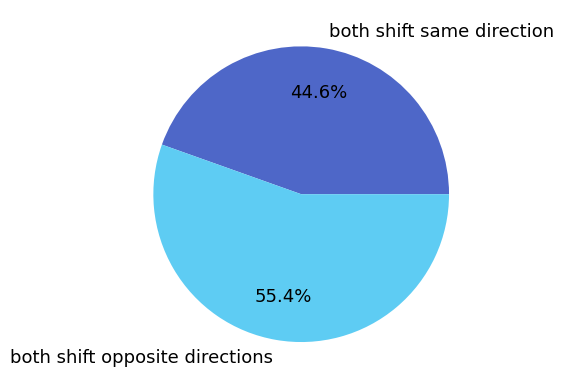

In [763]:
df = pd.DataFrame(
    {"counts": counts},
    index=items,
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

### Confusion matrix for dyads

In [722]:
opponents = list(trait_df['opponent'])

In [723]:
early_shift_class_player = early_shift_class

In [724]:
early_shift_class_opponent = []

for i, opponent in enumerate(opponents):
    early_shift_class = trait_df['fast_shift_class'][opponent]
    early_shift_class_opponent.append(early_shift_class)

trait_df['early_shift_class_opponent'] = early_shift_class_opponent

In [725]:
# Importing LabelEncoder from Sklearn 
# library from preprocessing Module.
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()

# Using .fit_transform function to fit label
# encoder and return encoded label

early_player_labels = le.fit_transform(early_shift_class_player)
early_opponent_labels = le.fit_transform(early_shift_class_opponent)

In [417]:
# confusion matrices

# 1. likelihood of pairings

In [726]:
early_dyads_once = {}

for pseudo, opp, player_class, opp_class in zip(
    pseudonyms,
    opponents,
    early_shift_class_player,
    early_shift_class_opponent
):
    # unique session/dyad identity, order-invariant
    early_dyad_id = tuple(sorted([pseudo, opp]))

    # class composition, order-invariant
    early_dyad_class = tuple(sorted([player_class, opp_class]))

    # keep only one row per real dyad
    if early_dyad_id not in early_dyads_once:
        early_dyads_once[early_dyad_id] = early_dyad_class

early_dyad_class_counts = Counter(early_dyads_once.values())

early_sorted_counts = sorted(early_dyad_class_counts.items())

early_types_of_dyads = [dyad for dyad, freq in early_sorted_counts]
early_frequency_of_dyads = [freq for dyad, freq in early_sorted_counts]

In [727]:
early_dyad_class_counts

Counter({('ADAPT', 'NO ADAPT'): 48,
         ('ADAPT', 'ADAPT'): 29,
         ('NO ADAPT', 'NO ADAPT'): 24})

In [416]:
# create list of player-opponent pairs
#dyads = list(zip(player_labels, opponent_labels))
early_dyads = list(zip(early_shift_class_player, early_shift_class_opponent))

early_count = Counter(early_dyads)

sorted_early_counts = sorted(early_count.items(), key=lambda tup: (tup[0][1], tup[0][0]))

types_of_early_dyads = [dyad for dyad, freq in sorted_early_counts]
frequency_of_early_dyads = [freq for dyad, freq in sorted_early_counts]

In [728]:
cmap = load_cmap("Mint")

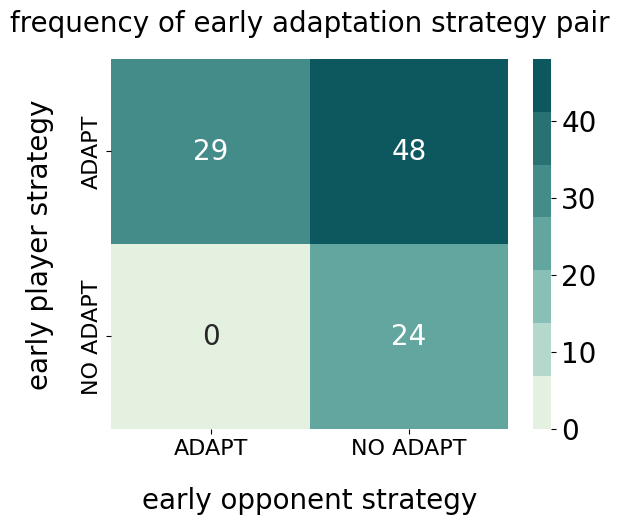

In [729]:
cm = pd.DataFrame(
    0,
    index=sorted(set(early_shift_class_player)),
    columns=sorted(set(early_shift_class_opponent))
)

for (player,opponent), freq in early_dyad_class_counts.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap, annot_kws={"size":20})

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("frequency of early adaptation strategy pair", fontsize=20, pad=20)
plt.xlabel('early opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('early player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

In [424]:
# confusion matrices

# 2. proportion scores

In [742]:
proportion_scores = list(trait_df['proportion_score'])

In [743]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='fast_shift_class',
    columns='early_shift_class_opponent',
    aggfunc='mean'
)

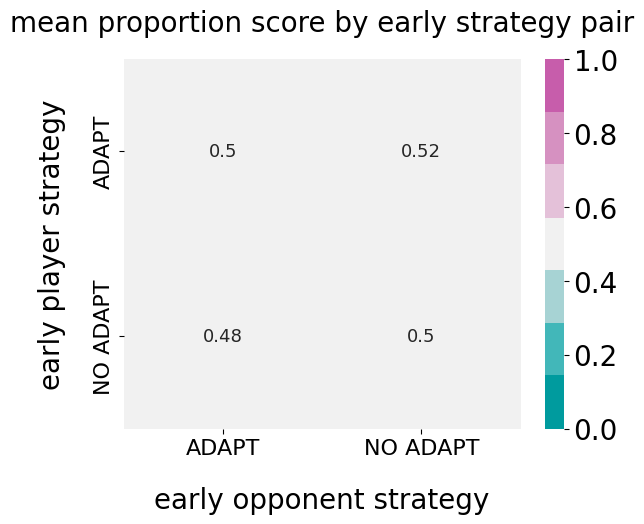

In [744]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean proportion score by early strategy pair", fontsize=20, pad=20)
plt.xlabel('early opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('early player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

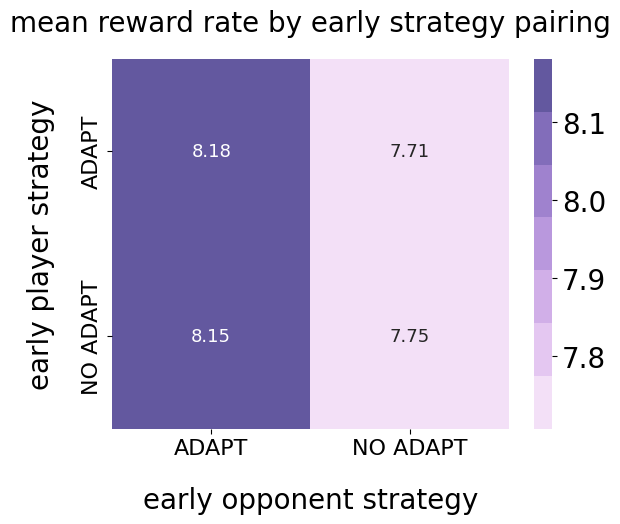

In [745]:
scores_per_second_matrix = pd.pivot_table(
    trait_df,
    values='scores_per_unit_time_socials',
    index='fast_shift_class',
    columns='early_shift_class_opponent',
    aggfunc='mean'
)

cmap = load_cmap("Purp")

sns.heatmap(
    scores_per_second_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean reward rate by early strategy pairing", fontsize=20, pad=20)
plt.xlabel('early opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('early player strategy',  fontsize=20, labelpad=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()

# cells: when row strategy meets column strategy, the former gets X points/s average

## Switch in social

### Average centrality slope across social for level of reactive switch

### Variance around the mean with sliding window for precision of players in their strategy

(calculate mean for a small window and variance around it then average across windows???)

In [524]:
# slope -> adaptation across social session 
# sliding-window variance -> precision/stability around the current strategy

In [509]:
# sliding window computation of variance to prevent inflated values from drift

def sliding_window_variance(x, window=5):

    x = np.asarray(x)

    local_vars = []

    for start in range(len(x) - window + 1):

        segment = x[start:start + window]

        local_mean = np.mean(segment)

        local_vars.append(
            np.mean((segment - local_mean)**2)
        )

    return np.mean(local_vars), np.array(local_vars)

In [510]:
results = {}

In [ ]:
from scipy.stats import linregress

# slow  change in strategy across the session
# positive/negative slope for more/less central over time, near zero for stable

for pseudonym, centrality in raw_social_centrality.items():

    results[pseudonym] = {}

    centrality = np.asarray(centrality)

    if len(centrality) < 2:
        continue

    # slope of the regression line
    slope = linregress(
        np.arange(len(centrality)),
        centrality
    ).slope

    results[pseudonym]['social_slope'] = slope

    # mean and array of local variances 
    mean_local_var, local_vars = sliding_window_variance(
    centrality,
    window=5
    )

    results[pseudonym]['local_variance'] = mean_local_var

    # detrended variance as alternative
    x = np.asarray(centrality)
    t = np.arange(len(x))

    fit = linregress(t, x)

    trend = fit.intercept + fit.slope * t

    residuals = x - trend

    precision_var = np.var(residuals)

    results[pseudonym]['detrended_variance'] = precision_var


In [552]:
slopes = []
detrended_var = []
window_vars = []
abs_slopes = []

for pseudonym, values in results.items():

    slope = results[pseudonym]['social_slope']
    var = results[pseudonym]['detrended_variance']
    w_var = results[pseudonym]['local_variance']

    slopes.append(slope)
    abs_slopes.append(abs(slope))
    detrended_var.append(var)
    window_vars.append(w_var)

Text(0, 0.5, 'N participants')

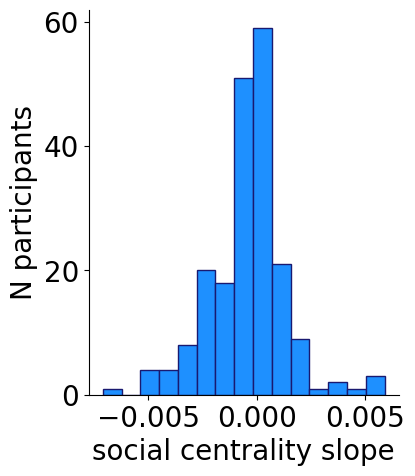

In [513]:
plt.figure(figsize=(4, 5))

plt.hist(slopes, bins=15, fill=True, edgecolor='midnightblue', color='dodgerblue')

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('social centrality slope', fontsize=20)
plt.ylabel('N participants', fontsize=20)

The average social centrality slope is small and significantly negative

In [514]:
from scipy.stats import ttest_1samp

ttest_1samp(slopes, 0)

TtestResult(statistic=np.float64(-3.5625330068572785), pvalue=np.float64(0.00045866417019093444), df=np.int64(201))

In [515]:
from scipy.stats import wilcoxon

wilcoxon(slopes)

WilcoxonResult(statistic=np.float64(6955.0), pvalue=np.float64(7.406073694262482e-05))

Text(0, 0.5, 'N participants')

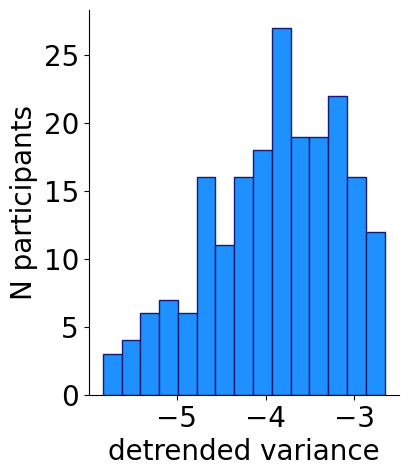

In [516]:
plt.figure(figsize=(4, 5))

sqrt_var = np.sqrt(detrended_var)

plt.hist(log_var, bins=15, fill=True, edgecolor='midnightblue', color='dodgerblue')

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('detrended variance', fontsize=20)
plt.ylabel('N participants', fontsize=20)

Text(0, 0.5, 'detrended variance')

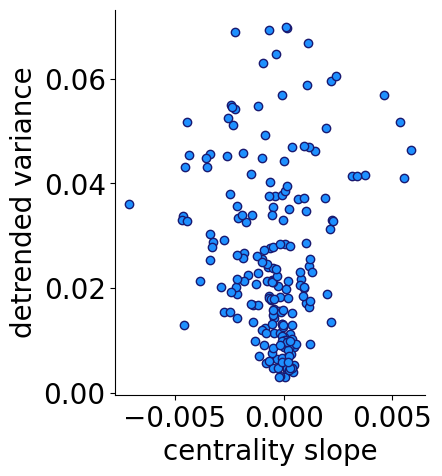

In [517]:
plt.figure(figsize=(4, 5))

plt.scatter(slopes, detrended_var, edgecolor='midnightblue', color='dodgerblue')

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('centrality slope', fontsize=20)
plt.ylabel('detrended variance', fontsize=20)

Text(0, 0.5, 'windowed variance')

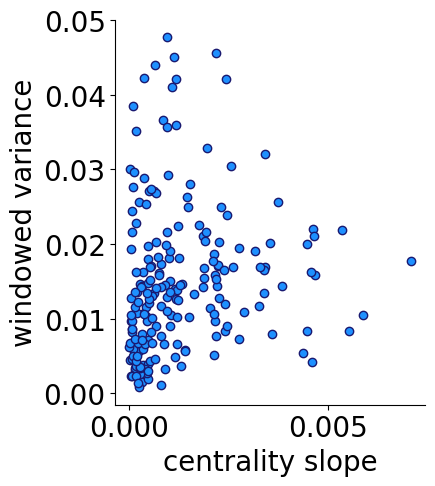

In [518]:
plt.figure(figsize=(4, 5))

plt.scatter(np.abs(slopes), window_vars, edgecolor='midnightblue', color='dodgerblue')

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('centrality slope', fontsize=20)
plt.ylabel('windowed variance', fontsize=20)

Becoming more or less central is not significantly related to variability

In [523]:
from scipy.stats import spearmanr
# is becoming more central vs less central related to variability?
spearmanr(slopes, detrended_var)

SignificanceResult(statistic=np.float64(-0.12515460060085853), pvalue=np.float64(0.07594299061498527))

In [522]:
spearmanr(slopes, window_vars)

SignificanceResult(statistic=np.float64(-0.06340462735340514), pvalue=np.float64(0.37000761085787287))

In [521]:
# is the amount of change related to variability?
spearmanr(np.abs(slopes), detrended_var)

SignificanceResult(statistic=np.float64(0.5061385265061319), pvalue=np.float64(1.5402260002246136e-14))

Participnts who changed strategy more throughout the social session also exhibited greater short-timescale variability around the current strategy

In [520]:
spearmanr(np.abs(slopes), window_vars)

SignificanceResult(statistic=np.float64(0.3118182195397688), pvalue=np.float64(6.260097801353979e-06))

Text(0, 0.5, 'N participants')

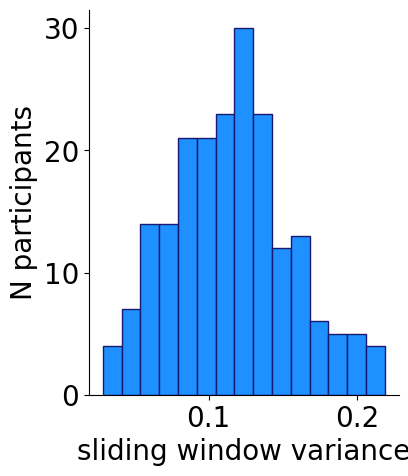

In [525]:
plt.figure(figsize=(4, 5))

plt.hist(np.sqrt(window_vars), bins=15, fill=True, edgecolor='midnightblue', color='dodgerblue')

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('sliding window variance', fontsize=20)
plt.ylabel('N participants', fontsize=20)

## Score

### Does proportion score increase as players are rated from 'least confident understanding' to 'most confident understanding'

In [764]:
final_20_pct = occupancy_dict['first_solos']['final_20_pct']['values']
first_20_pct = occupancy_dict['socials']['first_20_pct']['values']

In [766]:
final_20_pct.keys()

dict_keys(['EN27', 'SH27', 'AW17', 'SP17', 'FA12', 'KA12', 'SL12', 'WM12', 'HC13', 'NK13', 'RD13', 'YL13', 'AV19', 'HH19', 'SB19', 'XG19', 'JS20', 'RR20', 'VC20', 'ZS20', 'BC03', 'EX03', 'NN03', 'PO03', 'RK10', 'RU10', 'TE10', 'TK10', 'JU19', 'SY19', 'CS20', 'KS20', 'MR15', 'RR15', 'YL15', 'YY15', 'DB04', 'GG04', 'AE14', 'JL14', 'KC14', 'MA14', 'RM14', 'WL14', 'CD18', 'HL18', 'HM18', 'JK18', 'SC18', 'SJ18', 'AW19', 'HL19', 'JL19', 'PT19', 'AL01', 'HQ01', 'IS01', 'NL01', 'ML02', 'SH02', 'JI04', 'JW04', 'AR10', 'MY10', 'CW11', 'IN11', 'CY17', 'RL17', 'KC21', 'LM21', 'LS21', 'NM21', 'JC02', 'KS02', 'AM09', 'MC09', 'AS12', 'NO12', 'SC12', 'TG12', 'CY20', 'MJ20', 'EH21', 'SP21', 'AD22', 'SS22', 'JW23', 'YL23', 'IP24', 'JP24', 'VW30', 'ZZ30', 'MP04', 'SH04', 'DD20', 'JK20', 'JL13', 'YW13', 'SI03', 'YL03', 'AP10', 'CZ10', 'ES10', 'HT10', 'NM10', 'NO10', 'WT10', 'YL10', 'FA13', 'MU13', 'SA13', 'SW13', 'CS15', 'SK15', 'CW17', 'EM17', 'EV17', 'MZ17', 'XL17', 'ZH17', 'HW03', 'TG03', 'XA03', 'YG03

**immediate strategy change:**

difference between slice onset centrality in the last 20% of the first solo and the first 10% of social

**gradual adaptation in social:**

fit linear regression to centrality across social trials and take the absolute value of the slope

**standardise both measures:**

z-score across participants (expresses each participant relevant to population average)

**"understanding" (reactive adjustment vs incremental adaptation) index:**

compares the extent to which a participant's adjustment occurred immediately versus gradually. 
higher values indicate rapid adjustment and relative stability after, whereas low values indicate little immediate adjustment and gradual change over the social session.

In [563]:
import numpy as np
from scipy.stats import zscore

occupancy_dict['early_switch_scores'] = {}
occupancy_dict['abs_early_switch_scores'] = {}
occupancy_dict['understanding_index'] = {}

pseudonyms = []
early_switch_scores = []
abs_early_switch_scores = []
abs_social_slopes = []

for pseudonym in first_10_pct.keys():

    if pseudonym not in final_20_pct:
        continue

    if pseudonym not in results:
        continue

    switch_score = (
        np.mean(first_10_pct[pseudonym])
        - np.mean(final_20_pct[pseudonym])
    )

    abs_switch_score = abs(switch_score)

    slope = results[pseudonym]['social_slope']

    pseudonyms.append(pseudonym)
    early_switch_scores.append(switch_score)
    abs_early_switch_scores.append(abs_switch_score)
    abs_social_slopes.append(abs(slope))

    occupancy_dict['early_switch_scores'][pseudonym] = switch_score
    occupancy_dict['abs_early_switch_scores'][pseudonym] = abs_switch_score

In [564]:
z_abs_switch = zscore(abs_early_switch_scores, nan_policy='omit')
z_abs_slope = zscore(abs_social_slopes, nan_policy='omit')

understanding_index = z_abs_switch - z_abs_slope

for pseudonym, ui in zip(pseudonyms, understanding_index):
    occupancy_dict['understanding_index'][pseudonym] = ui

Text(0, 0.5, 'abs centrality slope')

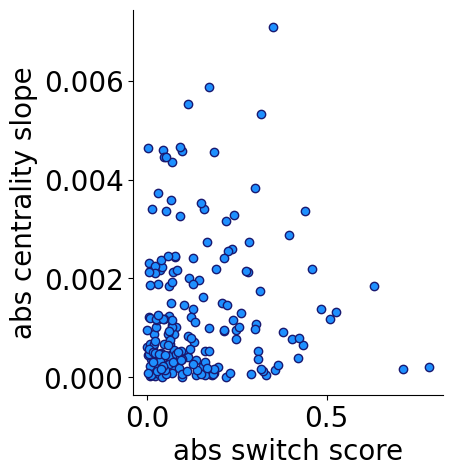

In [555]:
plt.figure(figsize=(4, 5))

plt.scatter(abs_early_switch_scores, abs_slopes, edgecolor='midnightblue', color='dodgerblue')

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('abs switch score', fontsize=20)
plt.ylabel('abs centrality slope', fontsize=20)

In [569]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

N = 202
Spearman rho = -0.030, p = 0.6731


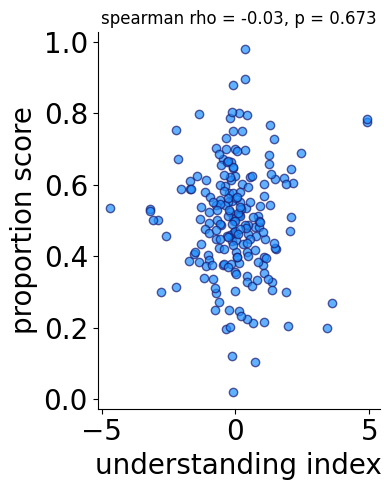

In [572]:
plot_df = pd.DataFrame({
    'understanding_index': pd.Series(
        occupancy_dict['understanding_index']
    )
})

plot_df = plot_df.join(
    trait_df[['proportion_score']],
    how='inner'
)

print(f'N = {len(plot_df)}')

rho, p = spearmanr(
    plot_df['understanding_index'],
    plot_df['proportion_score']
)

print(f"Spearman rho = {rho:.3f}, p = {p:.4g}")

plt.figure(figsize=(4, 5))

plt.scatter(
    plot_df['understanding_index'],
    plot_df['proportion_score'],
    edgecolor='midnightblue',
    color='dodgerblue',
    alpha=0.7)

ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=20)
ax.spines[['right', 'top']].set_visible(False)

plt.xlabel('understanding index', fontsize=20)
plt.ylabel('proportion score', fontsize=20)

plt.title(
    f'spearman rho = {rho:.2f}, p = {p:.3g}'
)

plt.tight_layout()
plt.show()

In [583]:
pd.to_pickle(occupancy_dict, '/Users/benny/Documents/swc/pickled_df/occupancy_dict.pkl')

In [585]:
pd.to_pickle(trait_df, "/Users/benny/Documents/swc/trait_analyses/trait_dataframes/df2.csv")